In [14]:
import pandas as pd



In [ ]:
import pandas as pd
import os

# File Location
folder = "."  # Data files should be in the same folder as this notebook
# List of 4 files
files = [
    "359JourneyDataExtract27Feb2023-05Mar2023.csv",
    "360JourneyDataExtract06Mar2023-12Mar2023.csv",
    "361JourneyDataExtract13Mar2023-19Mar2023.csv",
    "362JourneyDataExtract20Mar2023-26Mar2023.csv"
]

# Load and combine all 4 files
all_data = []
for file in files:
    path = os.path.join(folder, file)
    df = pd.read_csv(path)
    print(f"Loaded {file} — {len(df):,} rows")
    all_data.append(df)

# Combine into one big dataframe
combined = pd.concat(all_data, ignore_index=True)

print(f"\nTotal rows combined: {len(combined):,}")
print(f"Total columns: {len(combined.columns)}")
print(f"\nColumn names: {combined.columns.tolist()}")

Loaded 359JourneyDataExtract27Feb2023-05Mar2023.csv — 148,038 rows
Loaded 360JourneyDataExtract06Mar2023-12Mar2023.csv — 118,541 rows


C:\Users\DELHI LAPTOP\AppData\Local\Temp\ipykernel_21136\2253508305.py:19: DtypeWarning: Columns (0: Start station number, 1: End station number) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


Loaded 361JourneyDataExtract13Mar2023-19Mar2023.csv — 158,548 rows
Loaded 362JourneyDataExtract20Mar2023-26Mar2023.csv — 147,469 rows

Total rows combined: 572,596
Total columns: 11

Column names: ['Number', 'Start date', 'Start station number', 'Start station', 'End date', 'End station number', 'End station', 'Bike number', 'Bike model', 'Total duration', 'Total duration (ms)']


In [16]:
# Look at first 5 rows
print("First 5 rows of data:")
print(combined.head())

print("\n")

# Check for any missing values
print("Missing values in each column:")
print(combined.isnull().sum())

First 5 rows of data:
      Number        Start date Start station number  \
0  129019506  2023-03-05 23:59                22180   
1  129019507  2023-03-05 23:59                 3504   
2  129019508  2023-03-05 23:59               300003   
3  129019509  2023-03-06 00:00                 3455   
4  129019504  2023-03-05 23:58                 1204   

                      Start station          End date End station number  \
0                   Cheapside, Bank  2023-03-06 00:24               1112   
1                 Moor Street, Soho  2023-03-06 02:07               1022   
2    Eel Brook Common, Walham Green  2023-03-06 00:11               1172   
3            Arundel Street, Temple  2023-03-06 00:14               3495   
4  Queen's Gate (North), Kensington  2023-03-06 00:12             300210   

                              End station  Bike number  Bike model  \
0               Nutford Place, Marylebone        20457     CLASSIC   
1            Brunswick Square, Bloomsbury        6

In [17]:
# Check the data types of each column
print(combined.dtypes)

print("\n")

# Check bike types
print("Bike types:")
print(combined['Bike model'].value_counts())

Number                   int64
Start date                 str
Start station number    object
Start station              str
End date                   str
End station number      object
End station                str
Bike number              int64
Bike model                 str
Total duration             str
Total duration (ms)      int64
dtype: object


Bike types:
Bike model
CLASSIC       530161
PBSC_EBIKE     42435
Name: count, dtype: int64


In [18]:
# Step 1 - Convert Start date to proper datetime
combined['Start date'] = pd.to_datetime(
    combined['Start date'], format='%Y-%m-%d %H:%M')

# Step 2 - Convert End date to proper datetime  
combined['End date'] = pd.to_datetime(
    combined['End date'], format='%Y-%m-%d %H:%M')

# Step 3 - Convert duration from milliseconds to minutes
combined['duration_mins'] = combined['Total duration (ms)'] / 60000

# Step 4 - Round to 2 decimal places
combined['duration_mins'] = combined['duration_mins'].round(2)

# Check results
print("Date column type now:", combined['Start date'].dtype)
print("\nDuration in minutes - first 5 values:")
print(combined['duration_mins'].head())
print("\nDuration stats:")
print(combined['duration_mins'].describe().round(2))

Date column type now: datetime64[us]

Duration in minutes - first 5 values:
0     24.84
1    127.89
2     11.20
3     14.26
4     14.16
Name: duration_mins, dtype: float64

Duration stats:
count    572596.00
mean         21.92
std         244.69
min           0.02
25%           7.27
50%          12.20
75%          19.60
max       48733.96
Name: duration_mins, dtype: float64


In [19]:
# Remove unrealistic journeys
# Less than 2 minutes = accidental hire
# More than 180 minutes = unreturned bike or error

before = len(combined)

combined = combined[
    (combined['duration_mins'] >= 2) & 
    (combined['duration_mins'] <= 180)
]

after = len(combined)
removed = before - after

print(f"Rows before cleaning: {before:,}")
print(f"Rows after cleaning:  {after:,}")
print(f"Rows removed:         {removed:,}")
print(f"Percentage removed:   {(removed/before*100):.2f}%")

print("\nDuration stats after cleaning:")
print(combined['duration_mins'].describe().round(2))


Rows before cleaning: 572,596
Rows after cleaning:  561,830
Rows removed:         10,766
Percentage removed:   1.88%

Duration stats after cleaning:
count    561830.00
mean         15.77
std          13.72
min           2.00
25%           7.47
50%          12.35
75%          19.67
max         179.98
Name: duration_mins, dtype: float64


In [20]:
# Extract useful time features from Start date
combined['hour']        = combined['Start date'].dt.hour
combined['day_of_week'] = combined['Start date'].dt.dayofweek  # 0=Monday, 6=Sunday
combined['day_name']    = combined['Start date'].dt.day_name()
combined['date']        = combined['Start date'].dt.date
combined['month']       = combined['Start date'].dt.month
combined['week']        = combined['Start date'].dt.isocalendar().week.astype(int)

# Create is_weekend column
combined['is_weekend']   = (combined['day_of_week'] >= 5).astype(int)

# Create is_rush_hour column
combined['is_rush_hour'] = combined['hour'].isin(
    [7, 8, 9, 17, 18, 19]).astype(int)

# Create is_ebike column
combined['is_ebike'] = (combined['Bike model'] == 'PBSC_EBIKE').astype(int)

# Check results
print("New columns added successfully!")
print("\nSample of new features:")
print(combined[['Start date', 'hour', 'day_name', 
                'is_weekend', 'is_rush_hour', 'is_ebike']].head(8))

print("\nRush hour journeys:", f"{combined['is_rush_hour'].sum():,}")
print("Weekend journeys:", f"{combined['is_weekend'].sum():,}")
print("E-bike journeys:", f"{combined['is_ebike'].sum():,}")

New columns added successfully!

Sample of new features:
           Start date  hour day_name  is_weekend  is_rush_hour  is_ebike
0 2023-03-05 23:59:00    23   Sunday           1             0         0
1 2023-03-05 23:59:00    23   Sunday           1             0         1
2 2023-03-05 23:59:00    23   Sunday           1             0         0
3 2023-03-06 00:00:00     0   Monday           0             0         0
4 2023-03-05 23:58:00    23   Sunday           1             0         0
5 2023-03-05 23:59:00    23   Sunday           1             0         0
7 2023-03-05 23:56:00    23   Sunday           1             0         0
8 2023-03-05 23:56:00    23   Sunday           1             0         0

Rush hour journeys: 268,114
Weekend journeys: 125,610
E-bike journeys: 41,793


In [21]:
import requests

print("Fetching London weather from Open-Meteo...")


url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": 51.5074,
    "longitude": -0.1278,
    "start_date": "2023-02-27",
    "end_date": "2023-03-26",
    "hourly": "temperature_2m,precipitation,windspeed_10m,relativehumidity_2m,weathercode",
    "timezone": "Europe/London"
}

response = requests.get(url, params=params, timeout=60)

if response.status_code == 200:
    print("Weather data fetched successfully!")
    weather_json = response.json()
    print(f"Hours of weather data: {len(weather_json['hourly']['time']):,}")
else:
    print(f"Error: {response.status_code}")



Fetching London weather from Open-Meteo...
Weather data fetched successfully!
Hours of weather data: 672


In [22]:
import numpy as np

# Convert weather JSON to a dataframe
weather = pd.DataFrame({
    'weather_hour':  pd.to_datetime(weather_json['hourly']['time']),
    'temperature':   weather_json['hourly']['temperature_2m'],
    'precipitation': weather_json['hourly']['precipitation'],
    'wind_speed':    weather_json['hourly']['windspeed_10m'],
    'humidity':      weather_json['hourly']['relativehumidity_2m'],
    'weather_code':  weather_json['hourly']['weathercode'],
})

# Add weather description
wmo_map = {
    0: 'Clear', 1: 'Mainly clear', 2: 'Partly cloudy', 3: 'Overcast',
    45: 'Fog', 48: 'Icy fog',
    51: 'Light drizzle', 53: 'Drizzle', 55: 'Heavy drizzle',
    61: 'Light rain', 63: 'Rain', 65: 'Heavy rain',
    71: 'Light snow', 73: 'Snow', 75: 'Heavy snow',
    80: 'Light showers', 81: 'Showers', 82: 'Heavy showers',
    95: 'Thunderstorm',
}
weather['weather_desc'] = weather['weather_code'].map(wmo_map).fillna('Other')

# Add useful binary flags
weather['is_raining'] = (weather['precipitation'] > 0).astype(int)
weather['is_cold']    = (weather['temperature'] < 5).astype(int)
weather['is_windy']   = (weather['wind_speed'] > 20).astype(int)

print("Weather dataframe created!")
print(f"Shape: {weather.shape}")
print("\nFirst 5 rows:")
print(weather.head())
print("\nWeather types in your data:")
print(weather['weather_desc'].value_counts())

Weather dataframe created!
Shape: (672, 10)

First 5 rows:
         weather_hour  temperature  precipitation  wind_speed  humidity  \
0 2023-02-27 00:00:00          0.6            0.0        10.8        73   
1 2023-02-27 01:00:00          0.2            0.0        12.1        81   
2 2023-02-27 02:00:00         -0.3            0.0        10.4        83   
3 2023-02-27 03:00:00         -0.5            0.0        10.5        83   
4 2023-02-27 04:00:00          0.2            0.0        11.4        80   

   weather_code   weather_desc  is_raining  is_cold  is_windy  
0             2  Partly cloudy           0        1         0  
1             2  Partly cloudy           0        1         0  
2             0          Clear           0        1         0  
3             0          Clear           0        1         0  
4             2  Partly cloudy           0        1         0  

Weather types in your data:
weather_desc
Overcast         308
Light drizzle    154
Clear             63
M

In [23]:
# Step 1 - Round each journey start time DOWN to the nearest hour

combined['weather_hour'] = combined['Start date'].dt.floor('h')

# Step 2 - Merge journey data with weather data on the hour
merged = combined.merge(weather, on='weather_hour', how='left')

# Step 3 - Check results
print(f"Rows before merge: {len(combined):,}")
print(f"Rows after merge:  {len(merged):,}")
print(f"Columns before: {len(combined.columns)}")
print(f"Columns after:  {len(merged.columns)}")

print("\nSample - journey with its weather:")
print(merged[['Start date', 'duration_mins', 
              'temperature', 'weather_desc', 
              'is_raining', 'is_rush_hour']].head(5))
print("\nAny missing weather values?")
print(merged['temperature'].isna().sum())

Rows before merge: 561,830
Rows after merge:  561,830
Columns before: 22
Columns after:  31

Sample - journey with its weather:
           Start date  duration_mins  temperature weather_desc  is_raining  \
0 2023-03-05 23:59:00          24.84          2.5     Overcast           0   
1 2023-03-05 23:59:00         127.89          2.5     Overcast           0   
2 2023-03-05 23:59:00          11.20          2.5     Overcast           0   
3 2023-03-06 00:00:00          14.26          1.1     Overcast           0   
4 2023-03-05 23:58:00          14.16          2.5     Overcast           0   

   is_rush_hour  
0             0  
1             0  
2             0  
3             0  
4             0  

Any missing weather values?
0


In [24]:
# Save the final merged dataset
output_file = r"C:\Users\DELHI LAPTOP\Documents\Python\TFL_Project\TFL_Santander_Weather_March2023.csv"

merged.to_csv(output_file, index=False)

print("File saved successfully!")
print(f"Location: {output_file}")
print(f"Total rows: {len(merged):,}")
print(f"Total columns: {len(merged.columns)}")
print(f"\nColumn names in your final dataset:")
for col in merged.columns:
    print(f"  - {col}")

File saved successfully!
Location: C:\Users\DELHI LAPTOP\Documents\Python\TFL_Project\TFL_Santander_Weather_March2023.csv
Total rows: 561,830
Total columns: 31

Column names in your final dataset:
  - Number
  - Start date
  - Start station number
  - Start station
  - End date
  - End station number
  - End station
  - Bike number
  - Bike model
  - Total duration
  - Total duration (ms)
  - duration_mins
  - hour
  - day_of_week
  - day_name
  - date
  - month
  - week
  - is_weekend
  - is_rush_hour
  - is_ebike
  - weather_hour
  - temperature
  - precipitation
  - wind_speed
  - humidity
  - weather_code
  - weather_desc
  - is_raining
  - is_cold
  - is_windy


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Reload the final dataset
merged = pd.read_csv(
    r"C:\Users\DELHI LAPTOP\Documents\Python\TFL_Project\TFL_Santander_Weather_March2023.csv"
)

# Fix date column back to datetime
merged['Start date'] = pd.to_datetime(merged['Start date'])

print(f"Dataset reloaded successfully!")
print(f"Rows: {len(merged):,}")
print(f"Columns: {len(merged.columns)}")

C:\Users\DELHI LAPTOP\AppData\Local\Temp\ipykernel_21136\515280611.py:7: DtypeWarning: Columns (0: Start station number, 1: End station number) have mixed types. Specify dtype option on import or set low_memory=False.
  merged = pd.read_csv(


Dataset reloaded successfully!
Rows: 561,830
Columns: 31


## Section 3 — Exploratory Data Analysis (EDA)

In this section we explore the dataset visually to understand 
patterns, distributions, and relationships between features. 
Each graph is chosen specifically because it reveals something 
important about the data that will inform our modelling decisions 
in Section 4.

We will create 6 key visualisations:
- Figure 1: Distribution of journey durations (target variable)
- Figure 2: Average journeys by hour of day
- Figure 3: Journey duration by weather condition
- Figure 4: Temperature vs journey duration
- Figure 5: Weekday vs weekend journey patterns
- Figure 6: Correlation heatmap of all numerical features

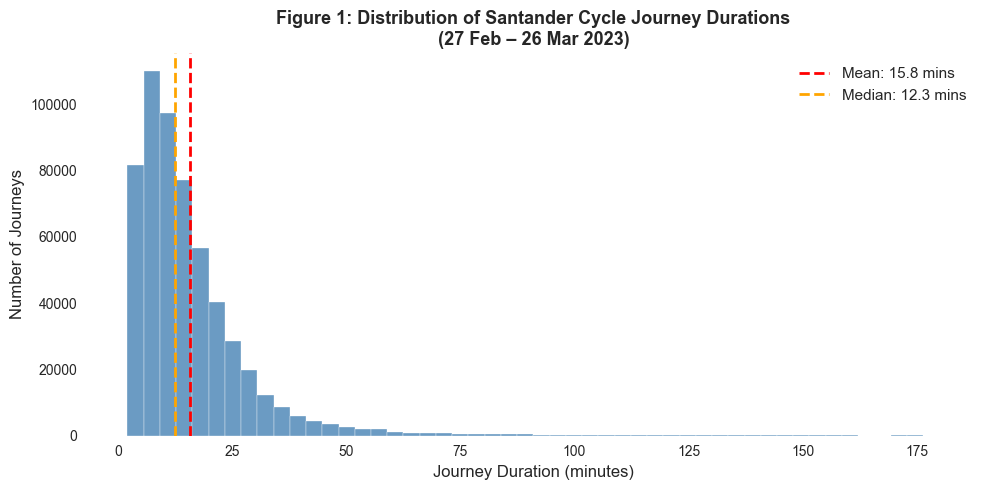

Figure 1 saved!


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style for all graphs
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# ── GRAPH 1: Distribution of journey duration ──────────────────
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

ax.hist(merged['duration_mins'], bins=50, 
        color='steelblue', edgecolor='white', alpha=0.8)
ax.set_xlabel('Journey Duration (minutes)', fontsize=12)
ax.set_ylabel('Number of Journeys', fontsize=12)
ax.set_title('Figure 1: Distribution of Santander Cycle Journey Durations\n(27 Feb – 26 Mar 2023)', 
             fontsize=13, fontweight='bold')
ax.axvline(merged['duration_mins'].mean(), 
           color='red', linestyle='--', linewidth=2,
           label=f"Mean: {merged['duration_mins'].mean():.1f} mins")
ax.axvline(merged['duration_mins'].median(), 
           color='orange', linestyle='--', linewidth=2,
           label=f"Median: {merged['duration_mins'].median():.1f} mins")
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('figure1_duration_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1 saved!")


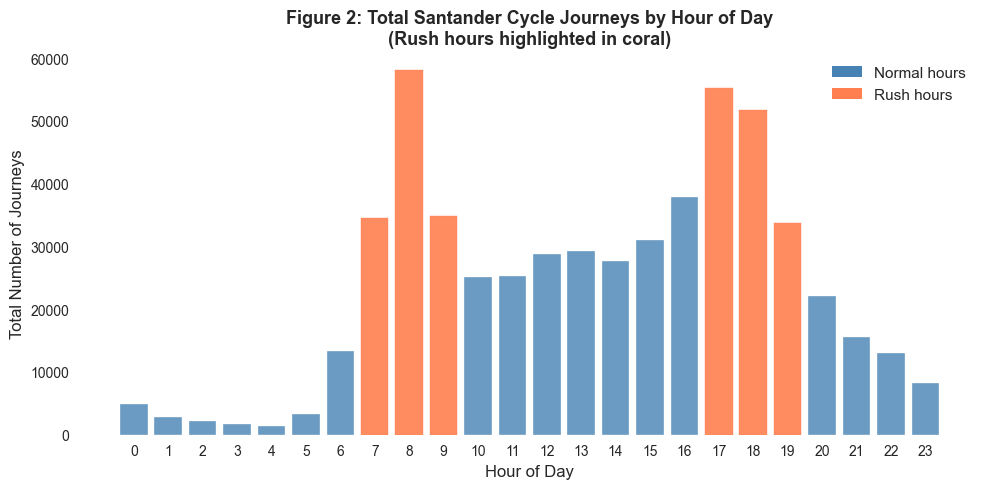

Figure 2 saved!


In [27]:
# ── GRAPH 2: Average journeys by hour of day ──────────────────
hourly = merged.groupby('hour').size().reset_index(name='journey_count')

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
bars = ax.bar(hourly['hour'], hourly['journey_count'], 
              color='steelblue', edgecolor='white', alpha=0.8)

# Highlight rush hours in different colour
rush_hours = [7, 8, 9, 17, 18, 19]
for bar, hour in zip(bars, hourly['hour']):
    if hour in rush_hours:
        bar.set_color('coral')
        bar.set_alpha(0.9)

ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Total Number of Journeys', fontsize=12)
ax.set_title('Figure 2: Total Santander Cycle Journeys by Hour of Day\n(Rush hours highlighted in coral)', 
             fontsize=13, fontweight='bold')
ax.set_xticks(range(0, 24))
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', label='Normal hours'),
                   Patch(facecolor='coral', label='Rush hours')]
ax.legend(handles=legend_elements, fontsize=11)
plt.tight_layout()
plt.savefig('figure2_hourly_journeys.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2 saved!")


C:\Users\DELHI LAPTOP\AppData\Local\Temp\ipykernel_21136\1205879732.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=weather_filtered,


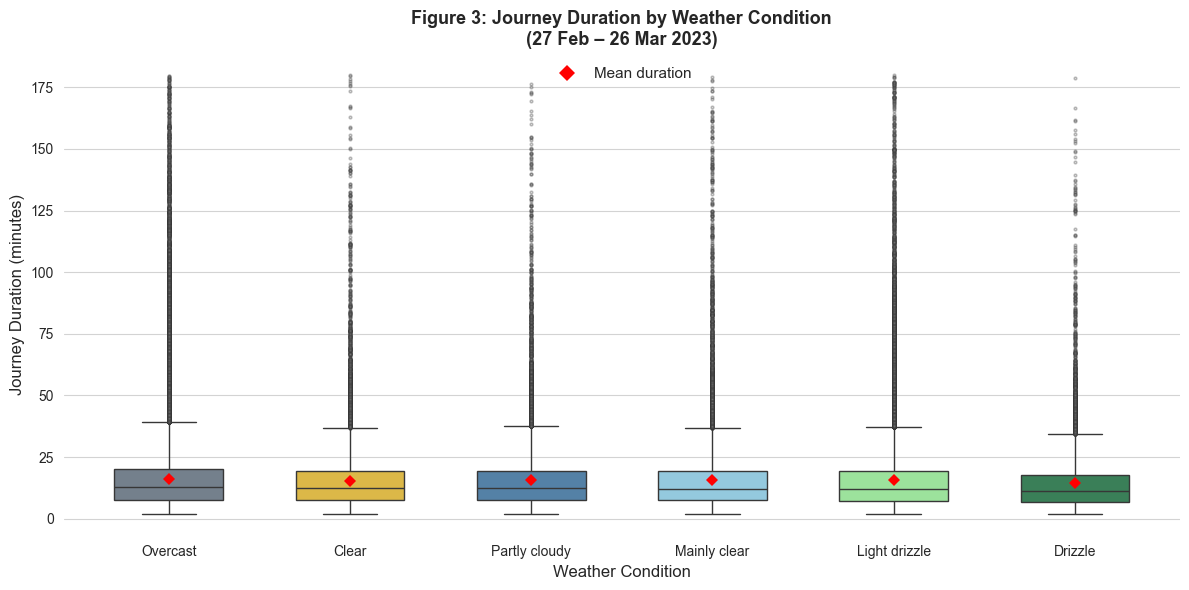

Figure 3 saved!


In [28]:
# ── GRAPH 3: Box plot — Duration by weather condition ──────────
# Define consistent weather colours
weather_colours = {
    'Clear':         '#F4C430',
    'Mainly clear':  '#87CEEB',
    'Partly cloudy': '#4682B4',
    'Overcast':      '#708090',
    'Light drizzle': '#90EE90',
    'Drizzle':       '#2E8B57'
}

# Keep top 6 weather conditions
top_weather = merged['weather_desc'].value_counts().head(6).index
weather_filtered = merged[merged['weather_desc'].isin(top_weather)]

# Sort by median
order = weather_filtered.groupby('weather_desc')['duration_mins'].median(
    ).sort_values(ascending=False).index

colour_list = [weather_colours.get(w, '#4682B4') for w in order]
# WHITE background
fig, ax = plt.subplots(figsize=(12, 6), facecolor='white')
ax.set_facecolor('white')

sns.boxplot(data=weather_filtered,
            x='weather_desc',
            y='duration_mins',
            order=order,
            palette=colour_list,
            width=0.6,
            flierprops=dict(marker='o', markerfacecolor='grey',
                          markersize=2, alpha=0.3),
            ax=ax)

ax.set_xlabel('Weather Condition', fontsize=12)
ax.set_ylabel('Journey Duration (minutes)', fontsize=12)
ax.set_title('Figure 3: Journey Duration by Weather Condition\n(27 Feb – 26 Mar 2023)',
             fontsize=13, fontweight='bold')
ax.tick_params(axis='x', labelsize=10)

# Light grey grid lines only on y axis
ax.yaxis.grid(True, color='lightgrey', linewidth=0.8)
ax.set_axisbelow(True)

# Add mean markers
means = weather_filtered.groupby('weather_desc')['duration_mins'].mean()
for i, condition in enumerate(order):
    ax.plot(i, means[condition], marker='D',
            color='red', markersize=6, zorder=3)

from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='D', color='w',
                          markerfacecolor='red', markersize=8,
                          label='Mean duration')]
ax.legend(handles=legend_elements, fontsize=11)

plt.tight_layout()
plt.savefig('figure3_weather_boxplot.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Figure 3 saved!")



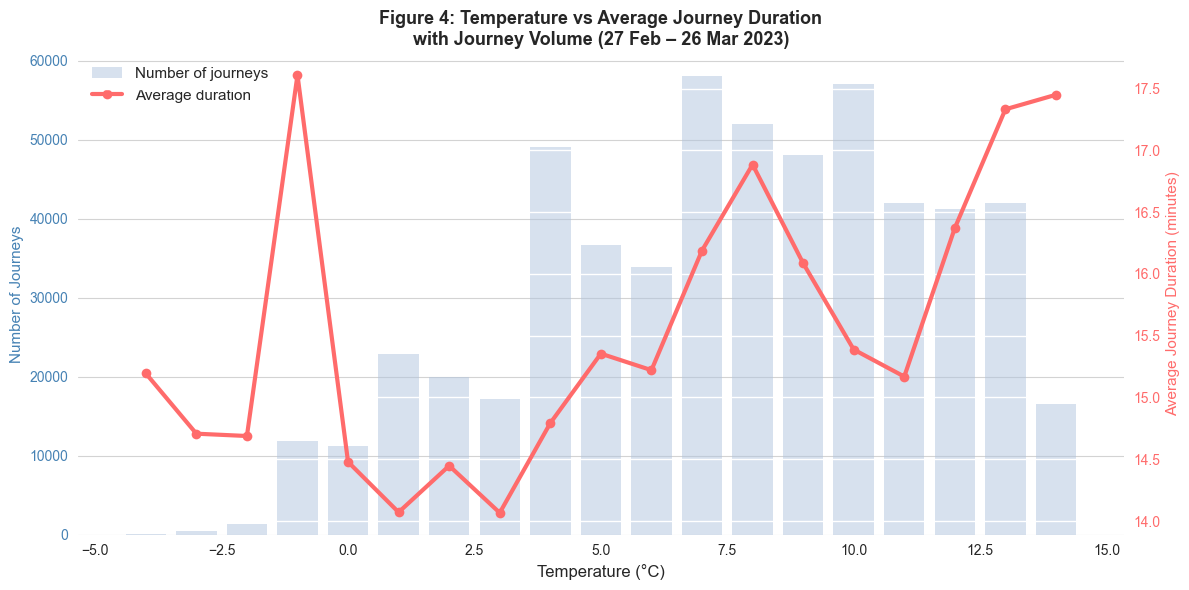

Figure 4 saved!

Key temperature insights:
 temp_rounded  avg_duration  journey_count
         -4.0     15.195170            147
         -3.0     14.706916            441
         -2.0     14.688158           1417
         -1.0     17.609702          11848
         -0.0     14.478627          11271
          1.0     14.071041          22826
          2.0     14.447547          20018
          3.0     14.066489          17167
          4.0     14.792561          49077
          5.0     15.354663          36640
          6.0     15.221017          33856
          7.0     16.189114          58085
          8.0     16.885012          51958
          9.0     16.086659          48150
         10.0     15.387957          57067
         11.0     15.169124          42046
         12.0     16.371604          41253
         13.0     17.332335          42049
         14.0     17.449889          16514


In [29]:
# ── GRAPH 4: Temperature vs Average Journey Duration ──────────

# Calculate average duration for each temperature (rounded to nearest degree)
merged['temp_rounded'] = merged['temperature'].round(0)
temp_avg = merged.groupby('temp_rounded').agg(
    avg_duration=('duration_mins', 'mean'),
    journey_count=('duration_mins', 'count')
).reset_index()

# Only keep temperatures with enough journeys to be meaningful
temp_avg = temp_avg[temp_avg['journey_count'] > 100]

fig, ax1 = plt.subplots(figsize=(12, 6), facecolor='white')
ax1.set_facecolor('white')

# Bar chart showing journey count (secondary info)
ax1.bar(temp_avg['temp_rounded'], temp_avg['journey_count'],
        color='lightsteelblue', alpha=0.5, label='Number of journeys')
ax1.set_ylabel('Number of Journeys', fontsize=11, color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
# Line chart showing average duration on second y axis
ax2 = ax1.twinx()
ax2.plot(temp_avg['temp_rounded'], temp_avg['avg_duration'],
         color='#FF6B6B', linewidth=3, marker='o',
         markersize=7, label='Average duration')
ax2.set_ylabel('Average Journey Duration (minutes)', 
               fontsize=11, color='#FF6B6B')
ax2.tick_params(axis='y', labelcolor='#FF6B6B')

# Labels
ax1.set_xlabel('Temperature (°C)', fontsize=12)
ax1.set_title('Figure 4: Temperature vs Average Journey Duration\n'
              'with Journey Volume (27 Feb – 26 Mar 2023)',
              fontsize=13, fontweight='bold')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, 
           fontsize=11, loc='upper left')
ax1.yaxis.grid(True, color='lightgrey', linewidth=0.8)
ax1.set_axisbelow(True)

plt.tight_layout()
plt.savefig('figure4_temperature_duration.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Figure 4 saved!")

# Print key insight numbers
print("\nKey temperature insights:")
print(temp_avg[['temp_rounded', 'avg_duration', 
                'journey_count']].to_string(index=False))

In [30]:
# Checking count at -1 and -2°C temperatures.
print(merged.groupby('temp_rounded')['duration_mins'].agg(
    ['mean', 'count']).sort_values('temp_rounded').head(15))

                   mean  count
temp_rounded                  
-4.0          15.195170    147
-3.0          14.706916    441
-2.0          14.688158   1417
-1.0          17.609702  11848
-0.0          14.478627  11271
 1.0          14.071041  22826
 2.0          14.447547  20018
 3.0          14.066489  17167
 4.0          14.792561  49077
 5.0          15.354663  36640
 6.0          15.221017  33856
 7.0          16.189114  58085
 8.0          16.885012  51958
 9.0          16.086659  48150
 10.0         15.387957  57067


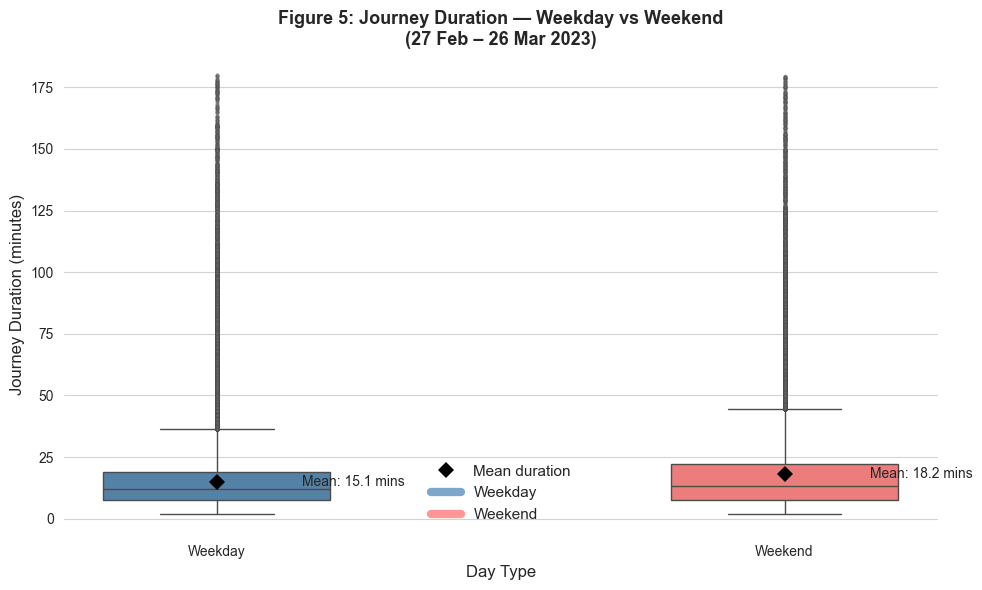

Figure 5 saved!

Verification:
Weekday mean: 15.07 mins (should be 15.07)
Weekend mean: 18.20 mins (should be 18.20)


In [31]:
# ── GRAPH 5: Box plot — Weekday vs Weekend duration ──────────

fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')
ax.set_facecolor('white')

# Create day type label
merged['day_type'] = merged['is_weekend'].map(
    {0: 'Weekday', 1: 'Weekend'})

# Define explicit order
day_order = ['Weekday', 'Weekend']

sns.boxplot(data=merged,
            x='day_type',
            y='duration_mins',
            order=day_order,
            hue='day_type',
            hue_order=day_order,
            palette={'Weekday': '#4682B4', 'Weekend': '#FF6B6B'},
            width=0.4,
            legend=False,
            flierprops=dict(marker='o', markerfacecolor='grey',
                          markersize=2, alpha=0.3),
            ax=ax)

# Add mean markers using actual calculated values
weekday_mean = merged[merged['day_type'] == 'Weekday']['duration_mins'].mean()
weekend_mean = merged[merged['day_type'] == 'Weekend']['duration_mins'].mean()

# Position 0 = Weekday, Position 1 = Weekend (matches day_order)
ax.plot(0, weekday_mean, marker='D', color='black', markersize=8, zorder=3)
ax.text(0.15, weekday_mean,
        f'Mean: {weekday_mean:.1f} mins',
        fontsize=10, va='center')
ax.plot(1, weekend_mean, marker='D', color='black', markersize=8, zorder=3)
ax.text(1.15, weekend_mean,
        f'Mean: {weekend_mean:.1f} mins',
        fontsize=10, va='center')

ax.set_xlabel('Day Type', fontsize=12)
ax.set_ylabel('Journey Duration (minutes)', fontsize=12)
ax.set_title('Figure 5: Journey Duration — Weekday vs Weekend\n'
             '(27 Feb – 26 Mar 2023)',
             fontsize=13, fontweight='bold')
ax.yaxis.grid(True, color='lightgrey', linewidth=0.8)
ax.set_axisbelow(True)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='D', color='w',
           markerfacecolor='black', markersize=8,
           label='Mean duration'),
    Line2D([0], [0], color='#4682B4', linewidth=6,
           alpha=0.7, label='Weekday'),
    Line2D([0], [0], color='#FF6B6B', linewidth=6,
           alpha=0.7, label='Weekend')
]
ax.legend(handles=legend_elements, fontsize=11)

plt.tight_layout()
plt.savefig('figure5_weekday_weekend.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Figure 5 saved!")

# Verify correct values shown
print(f"\nVerification:")
print(f"Weekday mean: {weekday_mean:.2f} mins (should be 15.07)")
print(f"Weekend mean: {weekend_mean:.2f} mins (should be 18.20)")


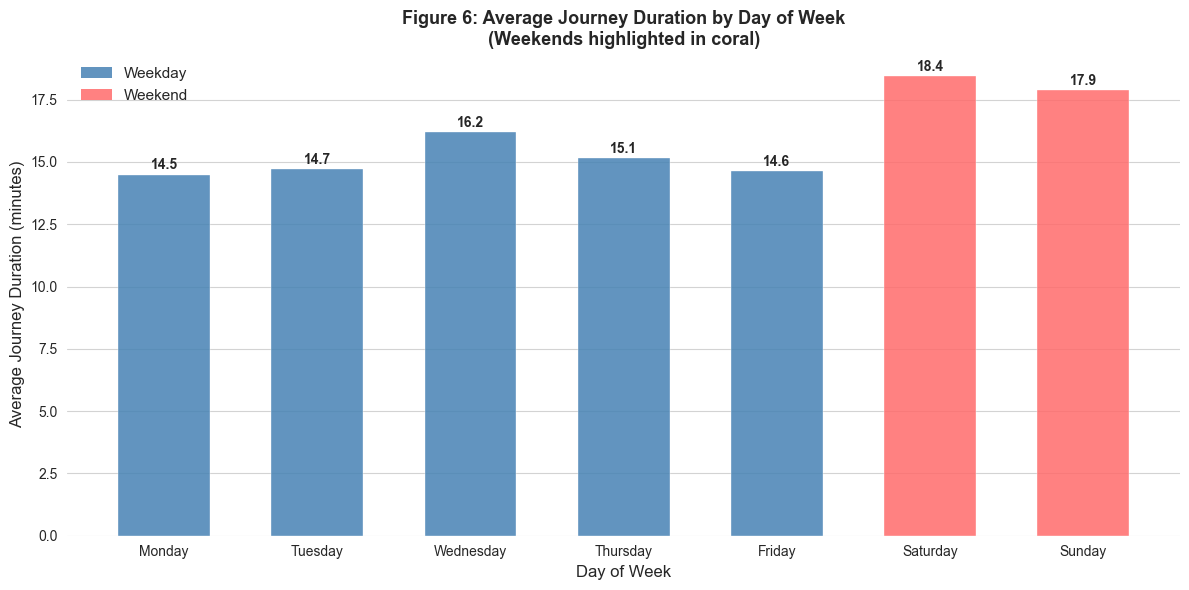

Figure 6 saved!

Day of week stats:
 day_name      mean  median  count
   Monday 14.481250   11.69  81394
  Tuesday 14.709055   12.04  94212
Wednesday 16.191981   13.15  95909
 Thursday 15.147500   12.27  88016
   Friday 14.619379   11.47  76689
 Saturday 18.447119   13.46  69824
   Sunday 17.886624   12.84  55786


In [32]:
# ── GRAPH 6: Duration vs Day of Week ──────────────────────────

day_order_full = ['Monday', 'Tuesday', 'Wednesday', 
                  'Thursday', 'Friday', 'Saturday', 'Sunday']

day_stats = merged.groupby('day_name')['duration_mins'].agg(
    ['mean', 'median', 'count']).reindex(day_order_full).reset_index()

fig, ax = plt.subplots(figsize=(12, 6), facecolor='white')
ax.set_facecolor('white')

colours = ['#4682B4', '#4682B4', '#4682B4', 
           '#4682B4', '#4682B4', '#FF6B6B', '#FF6B6B']

bars = ax.bar(day_stats['day_name'], day_stats['mean'],
              color=colours, edgecolor='white', 
              alpha=0.85, width=0.6)
# Add value labels on top of each bar
for bar, val in zip(bars, day_stats['mean']):
    ax.text(bar.get_x() + bar.get_width()/2, 
            bar.get_height() + 0.1,
            f'{val:.1f}', ha='center', 
            va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Day of Week', fontsize=12)
ax.set_ylabel('Average Journey Duration (minutes)', fontsize=12)
ax.set_title('Figure 6: Average Journey Duration by Day of Week\n'
             '(Weekends highlighted in coral)',
             fontsize=13, fontweight='bold')
ax.yaxis.grid(True, color='lightgrey', linewidth=0.8)
ax.set_axisbelow(True)
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4682B4', alpha=0.85, label='Weekday'),
    Patch(facecolor='#FF6B6B', alpha=0.85, label='Weekend')
]
ax.legend(handles=legend_elements, fontsize=11)

plt.tight_layout()
plt.savefig('figure6_day_of_week.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Figure 6 saved!")
print("\nDay of week stats:")
print(day_stats[['day_name', 'mean', 'median', 'count']].to_string(index=False))

Rush vs Non-Rush stats:
                mean  median   count
hour_type                           
Non-Rush Hour  16.38   12.18  293716
Rush Hour      15.10   12.50  268114


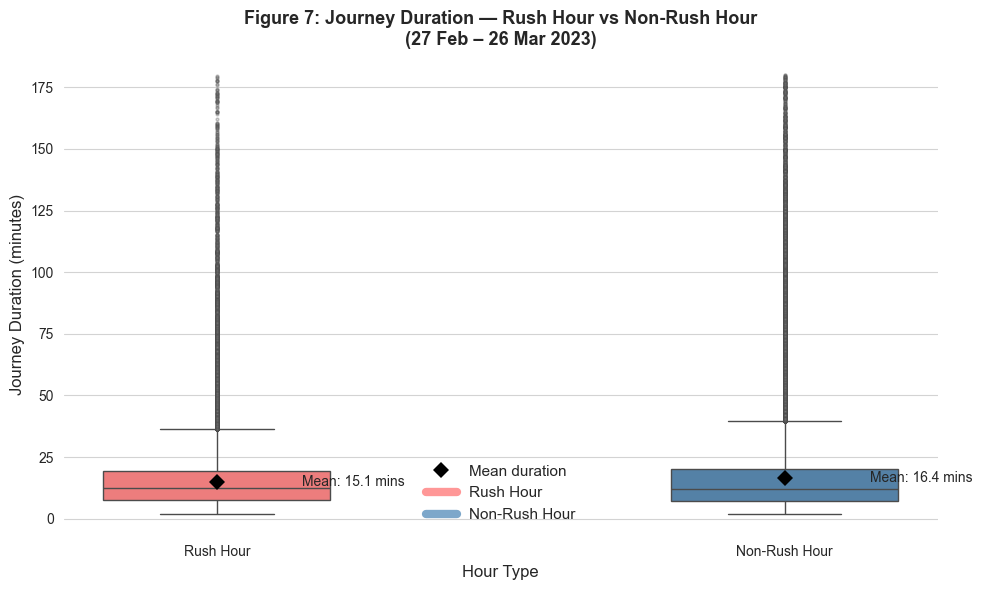

Figure 7 saved!

Verification:
Rush Hour mean: 15.10 mins
Non-Rush Hour mean: 16.38 mins


In [33]:
# ── GRAPH 7: Rush vs Non-Rush Hours ───────────────────────────

merged['hour_type'] = merged['is_rush_hour'].map(
    {0: 'Non-Rush Hour', 1: 'Rush Hour'})

rush_stats = merged.groupby('hour_type')['duration_mins'].agg(
    ['mean', 'median', 'count']).round(2)
print("Rush vs Non-Rush stats:")
print(rush_stats)

fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')
ax.set_facecolor('white')
sns.boxplot(data=merged,
            x='hour_type',
            y='duration_mins',
            order=['Rush Hour', 'Non-Rush Hour'],
            hue='hour_type',
            hue_order=['Rush Hour', 'Non-Rush Hour'],
            palette={
                'Rush Hour': '#FF6B6B',
                'Non-Rush Hour': '#4682B4'
            },
            width=0.4,
            legend=False,
            flierprops=dict(marker='o', markerfacecolor='grey',
                          markersize=2, alpha=0.3),
            ax=ax)
# Add verified mean markers
rush_mean = merged[merged['hour_type'] == 'Rush Hour']['duration_mins'].mean()
nonrush_mean = merged[merged['hour_type'] == 'Non-Rush Hour']['duration_mins'].mean()

ax.plot(0, rush_mean, marker='D', color='black', markersize=8, zorder=3)
ax.text(0.15, rush_mean,
        f'Mean: {rush_mean:.1f} mins',
        fontsize=10, va='center')

ax.plot(1, nonrush_mean, marker='D', color='black', markersize=8, zorder=3)
ax.text(1.15, nonrush_mean,
        f'Mean: {nonrush_mean:.1f} mins',
        fontsize=10, va='center')
ax.set_xlabel('Hour Type', fontsize=12)
ax.set_ylabel('Journey Duration (minutes)', fontsize=12)
ax.set_title('Figure 7: Journey Duration — Rush Hour vs Non-Rush Hour\n'
             '(27 Feb – 26 Mar 2023)',
             fontsize=13, fontweight='bold')
ax.yaxis.grid(True, color='lightgrey', linewidth=0.8)
ax.set_axisbelow(True)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='D', color='w',
           markerfacecolor='black', markersize=8,
           label='Mean duration'),
    Line2D([0], [0], color='#FF6B6B', linewidth=6,
           alpha=0.7, label='Rush Hour'),
    Line2D([0], [0], color='#4682B4', linewidth=6,
           alpha=0.7, label='Non-Rush Hour')
]
ax.legend(handles=legend_elements, fontsize=11)
plt.tight_layout()
plt.savefig('figure7_rush_nonrush.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Figure 7 saved!")

print(f"\nVerification:")
print(f"Rush Hour mean: {rush_mean:.2f} mins")
print(f"Non-Rush Hour mean: {nonrush_mean:.2f} mins")

In [34]:
print(merged.groupby('hour_type')['duration_mins'].agg(['mean','median','count']).round(2))

                mean  median   count
hour_type                           
Non-Rush Hour  16.38   12.18  293716
Rush Hour      15.10   12.50  268114


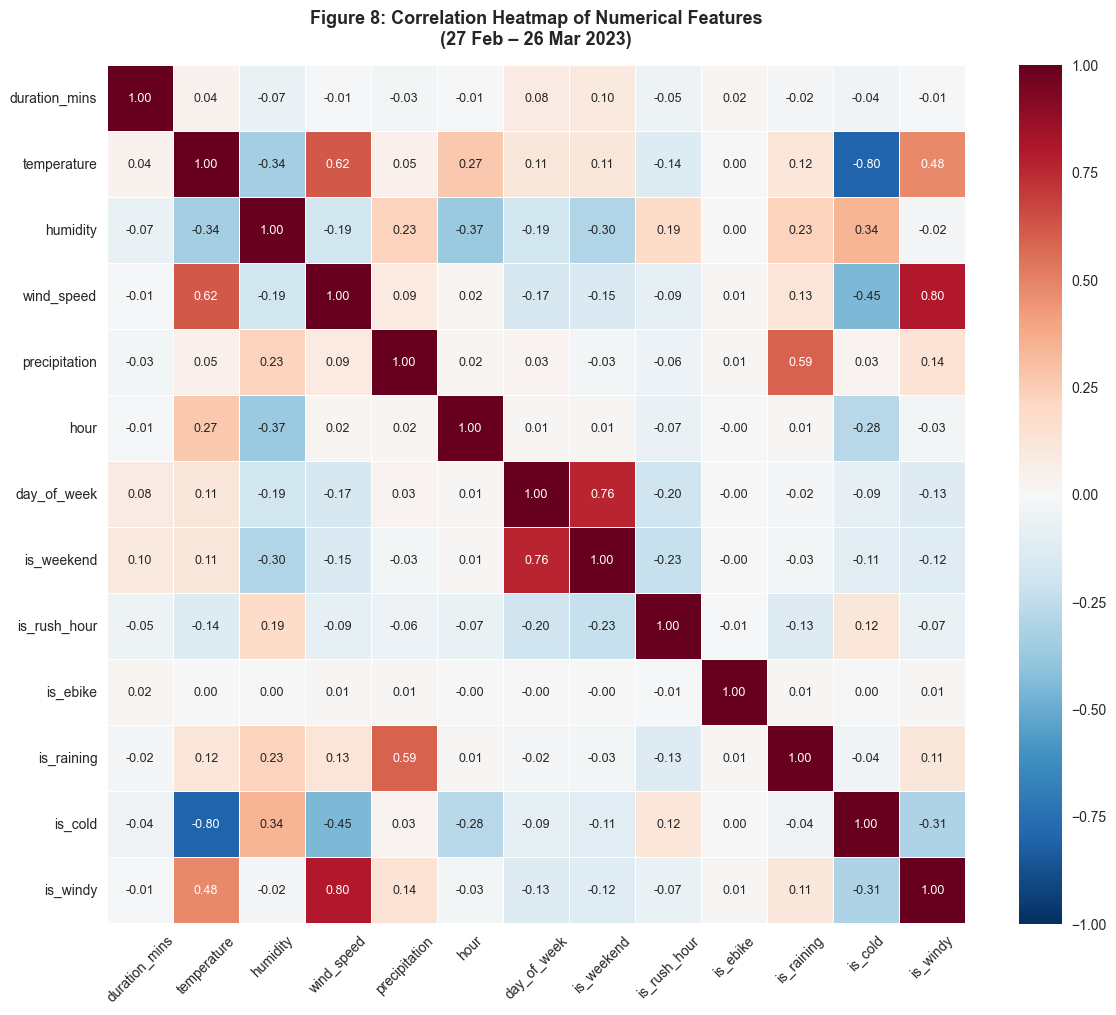

Heatmap saved!

Top correlations with duration_mins:
is_weekend       0.10
day_of_week      0.08
humidity        -0.07
is_rush_hour    -0.05
temperature      0.04
is_cold         -0.04
precipitation   -0.03
is_raining      -0.02
is_ebike         0.02
wind_speed      -0.01
hour            -0.01
is_windy        -0.01
Name: duration_mins, dtype: float64


In [35]:
# ── Eight GRAPH: Correlation Heatmap ──────────────────────────

corr_features = [
    'duration_mins',
    'temperature',
    'humidity',
    'wind_speed',
    'precipitation',
    'hour',
    'day_of_week',
    'is_weekend',
    'is_rush_hour',
    'is_ebike',
    'is_raining',
    'is_cold',
    'is_windy'
]

corr_matrix = merged[corr_features].corr().round(2)
fig, ax = plt.subplots(figsize=(12, 10), facecolor='white')
ax.set_facecolor('white')

sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='RdBu_r',
            center=0,
            vmin=-1,
            vmax=1,
            square=True,
            linewidths=0.5,
            linecolor='white',
            annot_kws={'size': 9},
            ax=ax)

ax.set_title('Figure 8: Correlation Heatmap of Numerical Features\n'
             '(27 Feb – 26 Mar 2023)',
             fontsize=13, fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=45, labelsize=10)
ax.tick_params(axis='y', rotation=0, labelsize=10)
plt.tight_layout()
plt.savefig('figure8_correlation_heatmap.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Heatmap saved!")

print("\nTop correlations with duration_mins:")
corr_with_duration = corr_matrix['duration_mins'].drop(
    'duration_mins').sort_values(key=abs, ascending=False)
print(corr_with_duration)

Running elbow method to find optimal K...
  K=2: inertia=345837
  K=3: inertia=272065
  K=4: inertia=242087
  K=5: inertia=223047
  K=6: inertia=207623
  K=7: inertia=193114
  K=8: inertia=181829
  K=9: inertia=169044


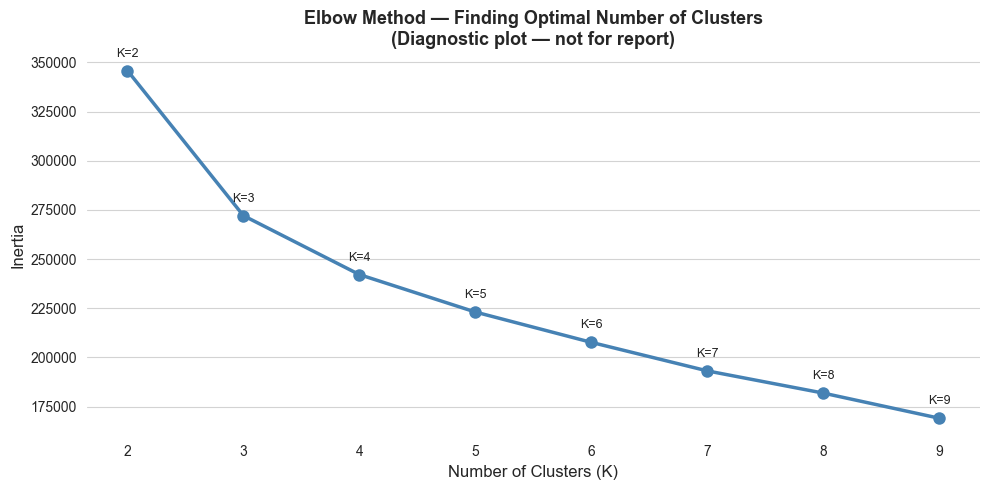


Look at the curve — where does it stop dropping sharply?
That is your optimal K value.


In [36]:
## Elbow Curve Code 
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Features for clustering
cluster_features = [
    'hour',
    'day_of_week',
    'is_weekend',
    'is_rush_hour',
    'temperature',
    'humidity',
    'wind_speed',
    'is_raining',
    'is_cold'
]
# Sample for speed
sample_df = merged[cluster_features].dropna().sample(
    n=50000, random_state=42)

# Standardise
scaler = StandardScaler()
X_scaled = scaler.fit_transform(sample_df)

print("Running elbow method to find optimal K...")

# Elbow method
inertia = []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)
    print(f"  K={k}: inertia={km.inertia_:.0f}")
    # Plot elbow curve
fig, ax = plt.subplots(figsize=(10, 5), facecolor='white')
ax.set_facecolor('white')
ax.plot(list(k_range), inertia, 'o-', linewidth=2.5,
        markersize=9, color='#4682B4')

# Annotate each point
for k, val in zip(k_range, inertia):
    ax.annotate(f'K={k}', xy=(k, val),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=9)

ax.set_xlabel('Number of Clusters (K)', fontsize=12)
ax.set_ylabel('Inertia', fontsize=12)
ax.set_title('Elbow Method — Finding Optimal Number of Clusters\n'
             '(Diagnostic plot — not for report)',
             fontsize=13, fontweight='bold')
ax.yaxis.grid(True, color='lightgrey', linewidth=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('elbow_curve_diagnostic.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("\nLook at the curve — where does it stop dropping sharply?")
print("That is your optimal K value.")

Running K-Means with K=4...

Cluster profiles:
         count  avg_duration  avg_hour  avg_temp  pct_weekend  pct_rush  \
cluster                                                                   
0        18837         15.64     14.68      9.28         0.00      0.55   
1        12099         14.63     10.83      2.35         0.05      0.64   
2        10516         18.26     13.98      8.72         1.00      0.24   
3         8548         14.97     14.47      9.64         0.00      0.42   

         pct_raining  
cluster               
0               0.00  
1               0.29  
2               0.29  
3               1.00  


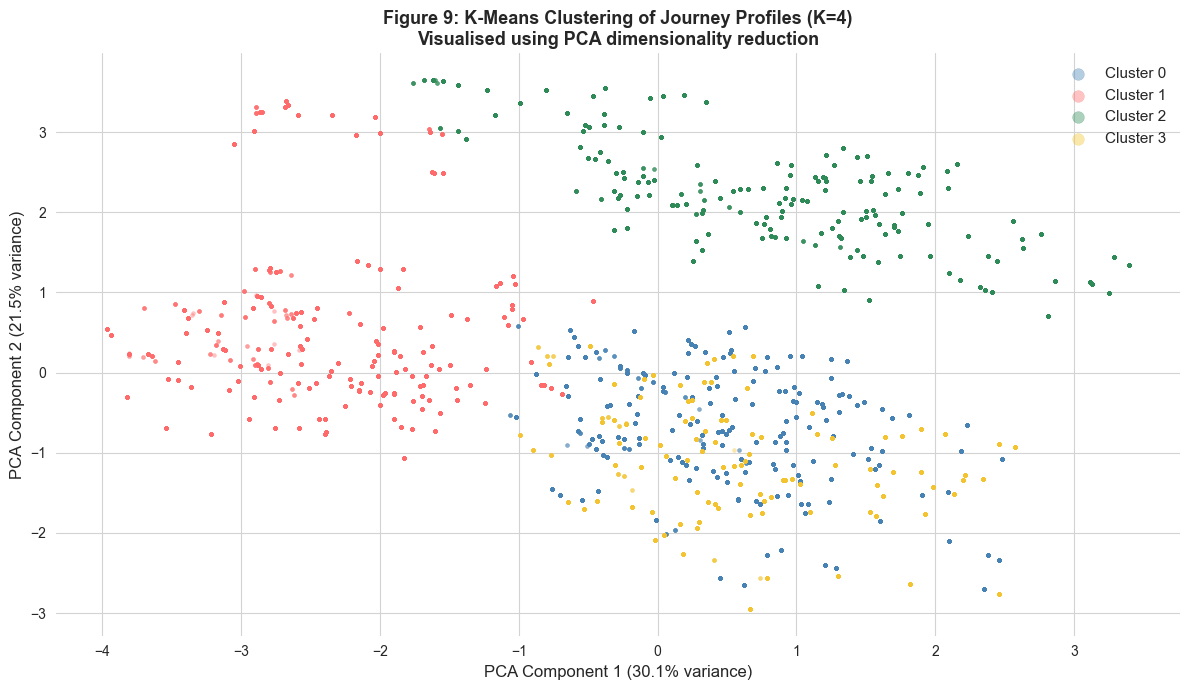


Figure 9 saved!

PCA explained variance: 51.5% total


In [37]:
from sklearn.decomposition import PCA

# ── FIGURE 9: K-Means Clustering with K=4 ─────────────────────

print("Running K-Means with K=4...")

# Use same sample and scaled data from elbow method
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels back to sample
sample_df = sample_df.copy()
sample_df['cluster'] = clusters

# Add duration back for profiling
sample_with_duration = merged[cluster_features + ['duration_mins']].dropna().sample(
    n=50000, random_state=42)
sample_with_duration['cluster'] = clusters

# ── STEP 1: Profile the clusters ──────────────────────────────
print("\nCluster profiles:")
profile = sample_with_duration.groupby('cluster').agg(
    count=('duration_mins', 'count'),
    avg_duration=('duration_mins', 'mean'),
    avg_hour=('hour', 'mean'),
    avg_temp=('temperature', 'mean'),
    pct_weekend=('is_weekend', 'mean'),
    pct_rush=('is_rush_hour', 'mean'),
    pct_raining=('is_raining', 'mean')
).round(2)
print(profile)

# ── STEP 2: PCA for 2D visualisation ──────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Cluster names based on profiles
cluster_names = {
    0: 'Cluster 0',
    1: 'Cluster 1', 
    2: 'Cluster 2',
    3: 'Cluster 3'
}

cluster_colours = {
    0: '#4682B4',
    1: '#FF6B6B',
    2: '#2E8B57',
    3: '#F4C430'
}

# ── STEP 3: Plot clusters ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7), facecolor='white')
ax.set_facecolor('white')

for cluster_id in range(4):
    mask = clusters == cluster_id
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=cluster_colours[cluster_id],
               label=f'Cluster {cluster_id}',
               alpha=0.4, s=8)

ax.set_xlabel(f'PCA Component 1 '
              f'({pca.explained_variance_ratio_[0]*100:.1f}% variance)',
              fontsize=12)
ax.set_ylabel(f'PCA Component 2 '
              f'({pca.explained_variance_ratio_[1]*100:.1f}% variance)',
              fontsize=12)
ax.set_title('Figure 9: K-Means Clustering of Journey Profiles (K=4)\n'
             'Visualised using PCA dimensionality reduction',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11, markerscale=3)
ax.yaxis.grid(True, color='lightgrey', linewidth=0.8)
ax.xaxis.grid(True, color='lightgrey', linewidth=0.8)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('figure9_kmeans_clusters.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("\nFigure 9 saved!")
print(f"\nPCA explained variance: "
      f"{pca.explained_variance_ratio_.sum()*100:.1f}% total")


## Section 4 — Machine Learning Prediction

This section implements supervised machine learning to predict 
Santander Cycle journey duration (duration_mins) — directly 
addressing the research question.

Following the data analysis steps outlined in CS5706 (Lecture 09),
the pipeline order is as follows :

Step 1: Feature preparation and target variable definition
Step 2: Train/test split using 80/20 holdout method
Step 3: Baseline model — Linear Regression
Step 4: Main model — Random Forest Regressor
Step 5: Model tuning using 5-fold cross-validation 
        (on training set ONLY — test set remains locked)
Step 6: Final evaluation on held-out test set
Step 7: Feature importance analysis

Evaluation metrics used (regression task):
- RMSE  (Root Mean Square Error) — main metric
- MAE   (Mean Absolute Error) — interpretable in minutes
- R²    (Coefficient of determination) — variance explained

The 80/20 holdout method was selected as the primary evaluation 
strategy. The test set is kept completely separate throughout 
all training and tuning to prevent data leakage and ensure 
unbiased performance estimation on unseen data.

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import cross_val_score
import numpy as np
import time
import warnings
warnings.filterwarnings('ignore')

print("=" * 55)
print("SECTION 4 — MACHINE LEARNING PIPELINE")
print("=" * 55)

# ── STEP 1: Define features and target ────────────────────────
features = [
    'hour',
    'day_of_week',
    'is_weekend',
    'is_rush_hour',
    'is_ebike',
    'temperature',
    'humidity',
    'wind_speed',
    'precipitation',
    'is_raining',
    'is_cold',
    'is_windy',
    'month',
    'week'
]

target = 'duration_mins'

# Remove any rows with missing values
ml_data = merged[features + [target]].dropna()

print(f"\nDataset for modelling: {len(ml_data):,} rows")
print(f"Features: {len(features)}")
print(f"Target: {target}")

# ── STEP 2: Train/test split — 80/20 holdout ──────────────────

X = ml_data[features]
y = ml_data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)
print(f"\nTrain/Test Split (80/20 Holdout Method):")
print(f"  Training set:  {len(X_train):,} rows ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Test set:      {len(X_test):,} rows  ({len(X_test)/len(X)*100:.1f}%)")
print(f"\nTest set is now LOCKED — not used until final evaluation")
print(f"All model training and tuning uses training set ONLY")

SECTION 4 — MACHINE LEARNING PIPELINE

Dataset for modelling: 561,830 rows
Features: 14
Target: duration_mins

Train/Test Split (80/20 Holdout Method):
  Training set:  449,464 rows (80.0%)
  Test set:      112,366 rows  (20.0%)

Test set is now LOCKED — not used until final evaluation
All model training and tuning uses training set ONLY


In [39]:
# ── STEP 3: Baseline Model — Linear Regression ────────────────

print("Training baseline Linear Regression model...")
print("(This is our simple baseline to beat)")

start_lr = time.time()
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_time = time.time() - start_lr

# Predict on test set
y_pred_lr = lr_model.predict(X_test)

# Calculate metrics
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_mae  = mean_absolute_error(y_test, y_pred_lr)
lr_r2   = r2_score(y_test, y_pred_lr)
print(f"\nBaseline Linear Regression Results:")
print(f"  RMSE:          {lr_rmse:.4f} minutes")
print(f"  MAE:           {lr_mae:.4f} minutes")
print(f"  R²:            {lr_r2:.4f}")
print(f"  Training time: {lr_time:.3f} seconds")
print(f"\nInterpretation:")
print(f"  On average, predictions are off by {lr_mae:.1f} minutes")
print(f"  Model explains {lr_r2*100:.1f}% of variance in journey duration")

Training baseline Linear Regression model...
(This is our simple baseline to beat)

Baseline Linear Regression Results:
  RMSE:          13.6484 minutes
  MAE:           8.7757 minutes
  R²:            0.0146
  Training time: 0.286 seconds

Interpretation:
  On average, predictions are off by 8.8 minutes
  Model explains 1.5% of variance in journey duration


In [40]:
# ── STEP 4: Random Forest Regressor ───────────────────────────

print("Training Random Forest model...")
print("(This may take 2-3 minutes on 449k rows — please wait)")

start_rf = time.time()

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=50,
    random_state=42,
    n_jobs=-1        # uses all CPU cores
)

rf_model.fit(X_train, y_train)
rf_time = time.time() - start_rf

# Predict on test set
y_pred_rf = rf_model.predict(X_test)

# Calculate metrics
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_mae  = mean_absolute_error(y_test, y_pred_rf)
rf_r2   = r2_score(y_test, y_pred_rf)

print(f"\nRandom Forest Results:")
print(f"  RMSE:          {rf_rmse:.4f} minutes")
print(f"  MAE:           {rf_mae:.4f} minutes")
print(f"  R²:            {rf_r2:.4f}")
print(f"  Training time: {rf_time:.3f} seconds")
print(f"\nImprovement over baseline:")
print(f"  RMSE improvement: {((lr_rmse - rf_rmse)/lr_rmse)*100:.1f}%")
print(f"  R² improvement:   {rf_r2 - lr_r2:.4f} absolute")
print(f"\nInterpretation:")
print(f"  On average, predictions are off by {rf_mae:.1f} minutes")
print(f"  Model explains {rf_r2*100:.1f}% of variance in journey duration")


Training Random Forest model...
(This may take 2-3 minutes on 449k rows — please wait)

Random Forest Results:
  RMSE:          13.5639 minutes
  MAE:           8.6880 minutes
  R²:            0.0268
  Training time: 65.809 seconds

Improvement over baseline:
  RMSE improvement: 0.6%
  R² improvement:   0.0122 absolute

Interpretation:
  On average, predictions are off by 8.7 minutes
  Model explains 2.7% of variance in journey duration


Running 5-fold cross-validation on training set...
(Test set remains completely untouched)

5-Fold Cross-Validation Results (R²):
  Fold 1: 0.0282
  Fold 2: 0.0271
  Fold 3: 0.0297
  Fold 4: 0.0260
  Fold 5: 0.0270

  Mean R²:  0.0276
  Std R²:   0.0013

Consistency check:
  Very consistent across folds — model is stable


Feature Importance Rankings:
   1. day_of_week          0.3359 (33.6%)
   2. temperature          0.1646 (16.5%)
   3. week                 0.1031 (10.3%)
   4. hour                 0.0964 (9.6%)
   5. humidity             0.0920 (9.2%)
   6. is_weekend           0.0698 (7.0%)
   7. wind_speed           0.0565 (5.7%)
   8. is_ebike             0.0342 (3.4%)
   9. is_rush_hour         0.0216 (2.2%)
  10. precipitation        0.0202 (2.0%)
  11. is_raining           0.0024 (0.2%)
  12. is_cold              0.0017 (0.2%)
  13. is_windy             0.0012 (0.1%)
  14. month                0.0003 (0.0%)


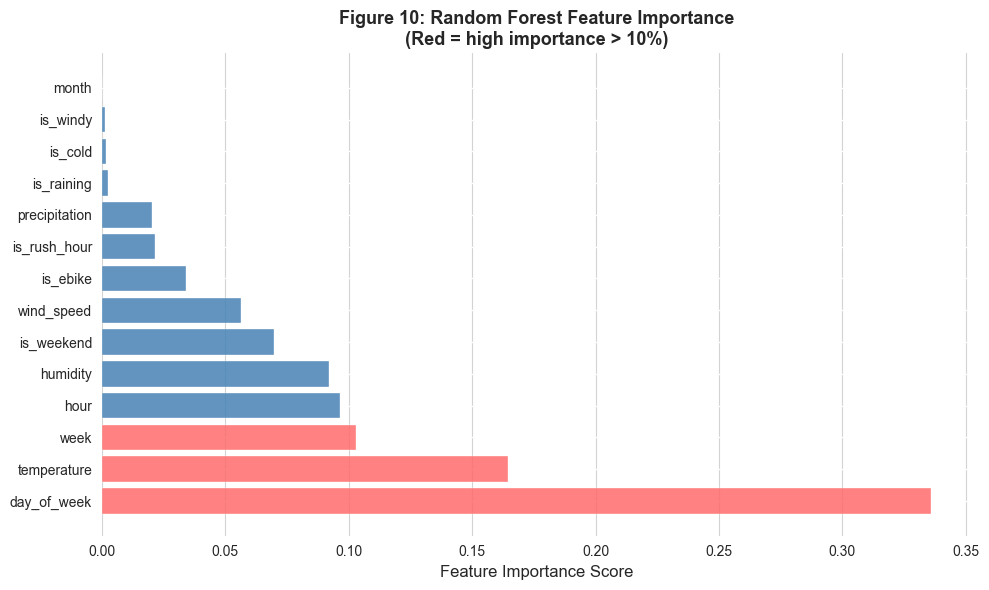


Feature importance plot saved!


In [41]:
# ── STEP 5: Cross-validation on training set only ─────────────

print("Running 5-fold cross-validation on training set...")
print("(Test set remains completely untouched)")

cv_scores = cross_val_score(
    rf_model, X_train, y_train,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

print(f"\n5-Fold Cross-Validation Results (R²):")
for i, score in enumerate(cv_scores):
    print(f"  Fold {i+1}: {score:.4f}")
print(f"\n  Mean R²:  {cv_scores.mean():.4f}")
print(f"  Std R²:   {cv_scores.std():.4f}")
print(f"\nConsistency check:")
if cv_scores.std() < 0.01:
    print("  Very consistent across folds — model is stable")
elif cv_scores.std() < 0.05:
    print("  Reasonably consistent across folds")
else:
    print("  High variance across folds — model is unstable")

# ── STEP 6: Feature Importance ────────────────────────────────

print("\n\nFeature Importance Rankings:")
feat_imp = pd.Series(
    rf_model.feature_importances_,
    index=features
).sort_values(ascending=False)

for i, (feat, imp) in enumerate(feat_imp.items()):
    print(f"  {i+1:2d}. {feat:<20} {imp:.4f} ({imp*100:.1f}%)")
    # ── STEP 7: Feature Importance Plot ───────────────────────────

fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')
ax.set_facecolor('white')

colours = ['#FF6B6B' if imp > 0.10 else '#4682B4' 
           for imp in feat_imp.values]

bars = ax.barh(feat_imp.index, feat_imp.values,
               color=colours, edgecolor='white', alpha=0.85)

ax.set_xlabel('Feature Importance Score', fontsize=12)
ax.set_title('Figure 10: Random Forest Feature Importance\n'
             '(Red = high importance > 10%)',
             fontsize=13, fontweight='bold')
ax.xaxis.grid(True, color='lightgrey', linewidth=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('figure10_feature_importance.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("\nFeature importance plot saved!")

In [42]:
# ── STEP 6: Log-Transformed Random Forest ─────────────────────
# Section 3.1 identified right skew in duration_mins (mean 15.8 > median 12.3)
# Log transform compresses the long tail and may improve model performance

print("="*55)
print("STEP 6 — LOG-TRANSFORMED RANDOM FOREST")
print("="*55)

# Apply log1p transform to target (log1p handles zero safely)
y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)

# Train RF on log-transformed target (same features, same config)
start_rf_log = time.time()
rf_log_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=50,
    random_state=42,
    n_jobs=-1
)
rf_log_model.fit(X_train, y_train_log)
rf_log_time = time.time() - start_rf_log

# Predict — convert back from log scale using expm1
y_pred_log_transformed = rf_log_model.predict(X_test)
y_pred_log_original    = np.expm1(y_pred_log_transformed)  
# Evaluate on ORIGINAL scale (minutes) for fair comparison
log_rmse = np.sqrt(mean_squared_error(y_test, y_pred_log_original))
log_mae  = mean_absolute_error(y_test, y_pred_log_original)
log_r2   = r2_score(y_test, y_pred_log_original)

# Also evaluate on log scale
log_rmse_logscale = np.sqrt(mean_squared_error(y_test_log, y_pred_log_transformed))
log_r2_logscale   = r2_score(y_test_log, y_pred_log_transformed)

print(f"\nLog-Transformed RF Results (evaluated in original minutes):")
print(f"  RMSE:          {log_rmse:.4f} minutes")
print(f"  MAE:           {log_mae:.4f} minutes")
print(f"  R²:            {log_r2:.4f}")
print(f"  Training time: {rf_log_time:.3f} seconds")
print(f"\nLog-scale R² (on transformed target): {log_r2_logscale:.4f}")
print(f"\n── Comparison Summary ──────────────────────────────────")
print(f"  Model                    RMSE      MAE      R²")
print(f"  Linear Regression        {lr_rmse:.4f}   {lr_mae:.4f}   {lr_r2:.4f}")
print(f"  RF (original target)     {rf_rmse:.4f}   {rf_mae:.4f}   {rf_r2:.4f}")
print(f"  RF (log-transformed)     {log_rmse:.4f}   {log_mae:.4f}   {log_r2:.4f}")

# Residual analysis for log model
residuals_log = y_test - y_pred_log_original
pct_within_5  = np.mean(np.abs(residuals_log) <= 5) * 100
pct_within_10 = np.mean(np.abs(residuals_log) <= 10) * 100
print(f"\nResidual analysis (log model):")
print(f"  Mean residual:     {residuals_log.mean():.4f} mins")
print(f"  % within ±5 mins:  {pct_within_5:.1f}%")
print(f"  % within ±10 mins: {pct_within_10:.1f}%")

STEP 6 — LOG-TRANSFORMED RANDOM FOREST

Log-Transformed RF Results (evaluated in original minutes):
  RMSE:          13.9980 minutes
  MAE:           8.2283 minutes
  R²:            -0.0365
  Training time: 76.072 seconds

Log-scale R² (on transformed target): 0.0291

── Comparison Summary ──────────────────────────────────
  Model                    RMSE      MAE      R²
  Linear Regression        13.6484   8.7757   0.0146
  RF (original target)     13.5639   8.6880   0.0268
  RF (log-transformed)     13.9980   8.2283   -0.0365

Residual analysis (log model):
  Mean residual:     3.3264 mins
  % within ±5 mins:  45.4%
  % within ±10 mins: 78.9%


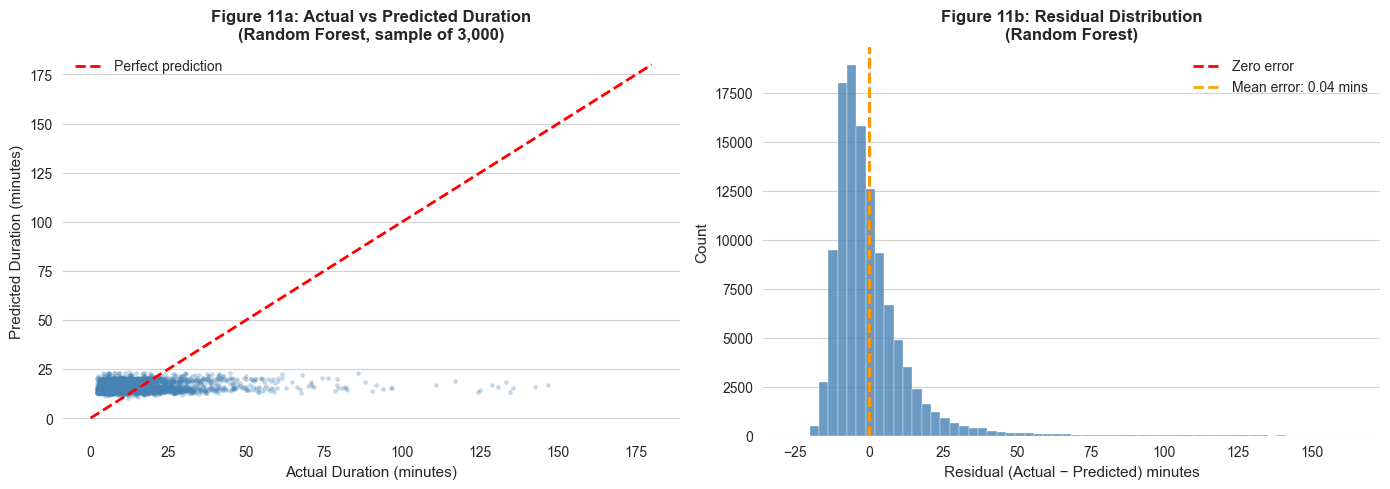

Figure 11 saved!

Residual analysis:
  Mean residual:   0.0432 mins
  Std residual:    13.5639 mins
  % within ±5 mins:  36.5%
  % within ±10 mins: 71.7%


In [36]:
# ── STEP 8: Actual vs Predicted Plot ──────────────────────────

# Sample 3000 points for clear visualisation
sample_idx = np.random.choice(len(y_test), 3000, replace=False)
y_test_sample  = y_test.iloc[sample_idx]
y_pred_sample  = y_pred_rf[sample_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='white')

# Plot 1 — Actual vs Predicted scatter
axes[0].set_facecolor('white')
axes[0].scatter(y_test_sample, y_pred_sample,
                alpha=0.3, s=8, color='#4682B4')
axes[0].plot([0, 180], [0, 180],
             color='red', linestyle='--',
             linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Duration (minutes)', fontsize=11)
axes[0].set_ylabel('Predicted Duration (minutes)', fontsize=11)
axes[0].set_title('Figure 11a: Actual vs Predicted Duration\n'
                  '(Random Forest, sample of 3,000)',
                  fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].yaxis.grid(True, color='lightgrey', linewidth=0.8)
axes[0].set_axisbelow(True)

# Plot 2 — Residual distribution
residuals = y_test - y_pred_rf
axes[1].set_facecolor('white')
axes[1].hist(residuals, bins=60,
             color='#4682B4', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--',
                linewidth=2, label='Zero error')
axes[1].axvline(residuals.mean(), color='orange',
                linestyle='--', linewidth=2,
                label=f'Mean error: {residuals.mean():.2f} mins')
axes[1].set_xlabel('Residual (Actual − Predicted) minutes',
                   fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title('Figure 11b: Residual Distribution\n'
                  '(Random Forest)',
                  fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].yaxis.grid(True, color='lightgrey', linewidth=0.8)
axes[1].set_axisbelow(True)
plt.tight_layout()
plt.savefig('figure11_rf_evaluation.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

print("Figure 11 saved!")
print(f"\nResidual analysis:")
print(f"  Mean residual:   {residuals.mean():.4f} mins")
print(f"  Std residual:    {residuals.std():.4f} mins")
print(f"  % within ±5 mins:  "
      f"{(abs(residuals) <= 5).mean()*100:.1f}%")
print(f"  % within ±10 mins: "
      f"{(abs(residuals) <= 10).mean()*100:.1f}%")

## Section 5 — HPC Implementation (Apache Spark)

In [4]:
import os
os.environ['PYSPARK_PYTHON'] = 'python'

from pyspark.sql import SparkSession
import time

print("Starting Apache Spark session...")


spark = SparkSession.builder \
    .appName("TFL_Cycles_HPC") \
    .master("local[*]") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print(f"\nSpark started successfully!")
print(f"Spark version: {spark.version}")
print(f"Master: {spark.sparkContext.master}")
print(f"App name: {spark.sparkContext.appName}")

Starting Apache Spark session...

Spark started successfully!
Spark version: 4.1.1
Master: local[*]
App name: TFL_Cycles_HPC


In [5]:
# ── LOAD DATA INTO SPARK DATAFRAME ────────────────────────────

print("Loading TFL dataset into Spark...")

csv_path = r"C:\Users\DELHI LAPTOP\Documents\Python\TFL_Project\TFL_Santander_Weather_March2023.csv"

sdf = spark.read.csv(
    csv_path,
    header=True,
    inferSchema=True
)

print(f"Spark DataFrame loaded successfully!")
print(f"Rows: {sdf.count():,}")
print(f"Columns: {len(sdf.columns)}")
print(f"\nSchema:")
sdf.printSchema()

Loading TFL dataset into Spark...
Spark DataFrame loaded successfully!
Rows: 561,830
Columns: 31

Schema:
root
 |-- Number: integer (nullable = true)
 |-- Start date: timestamp (nullable = true)
 |-- Start station number: string (nullable = true)
 |-- Start station: string (nullable = true)
 |-- End date: timestamp (nullable = true)
 |-- End station number: string (nullable = true)
 |-- End station: string (nullable = true)
 |-- Bike number: integer (nullable = true)
 |-- Bike model: string (nullable = true)
 |-- Total duration: string (nullable = true)
 |-- Total duration (ms): integer (nullable = true)
 |-- duration_mins: double (nullable = true)
 |-- hour: integer (nullable = true)
 |-- day_of_week: integer (nullable = true)
 |-- day_name: string (nullable = true)
 |-- date: date (nullable = true)
 |-- month: integer (nullable = true)
 |-- week: integer (nullable = true)
 |-- is_weekend: integer (nullable = true)
 |-- is_rush_hour: integer (nullable = true)
 |-- is_ebike: integer (n

In [8]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import RandomForestRegressor as SparkRF
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml import Pipeline
from pyspark.sql.functions import col
import time

print("Building Spark ML Pipeline...")

# ── STEP 1: Select features and target ────────────────────────

spark_features = [
    'hour',
    'day_of_week',
    'is_weekend',
    'is_rush_hour',
    'is_ebike',
    'temperature',
    'humidity',
    'wind_speed',
    'precipitation',
    'is_raining',
    'is_cold',
    'is_windy',
    'month',
    'week'
]

# Select only needed columns and drop nulls
spark_data = sdf.select(
    spark_features + ['duration_mins']
).dropna()

print(f"Rows after dropna: {spark_data.count():,}")

# ── STEP 2: Train/test split ───────────────────────────────────
train_sdf, test_sdf = spark_data.randomSplit(
    [0.8, 0.2], seed=42)

print(f"\nSpark Train/Test Split:")
print(f"  Training rows: {train_sdf.count():,}")
print(f"  Test rows:     {test_sdf.count():,}")

# ── STEP 3: Build pipeline ────────────────────────────────────
assembler = VectorAssembler(
    inputCols=spark_features,
    outputCol='features'
)

rf_spark = SparkRF(
    featuresCol='features',
    labelCol='duration_mins',
    numTrees=100,
    maxDepth=10,
    seed=42
)

pipeline = Pipeline(stages=[assembler, rf_spark])

print("\nPipeline built successfully!")
print("Stages: VectorAssembler → RandomForestRegressor")


Building Spark ML Pipeline...
Rows after dropna: 561,830

Spark Train/Test Split:
  Training rows: 449,517
  Test rows:     112,313

Pipeline built successfully!
Stages: VectorAssembler → RandomForestRegressor


In [9]:
# ── STEP 4: Train the Spark model and evaluate ────────────────

print("Training Spark Random Forest model...")


# Record start time
start_spark = time.time()

# Train the model
spark_model = pipeline.fit(train_sdf)

# Record training time
spark_train_time = time.time() - start_spark

print(f"\nSpark model trained successfully!")
print(f"Training time: {spark_train_time:.2f} seconds")

# Make predictions on test set
print("\nMaking predictions on test set...")
predictions = spark_model.transform(test_sdf)

# Evaluate performance
evaluator_rmse = RegressionEvaluator(
    labelCol='duration_mins',
    predictionCol='prediction',
    metricName='rmse'
)

evaluator_mae = RegressionEvaluator(
    labelCol='duration_mins',
    predictionCol='prediction',
    metricName='mae'
)

evaluator_r2 = RegressionEvaluator(
    labelCol='duration_mins',
    predictionCol='prediction',
    metricName='r2'
)

spark_rmse = evaluator_rmse.evaluate(predictions)
spark_mae  = evaluator_mae.evaluate(predictions)
spark_r2   = evaluator_r2.evaluate(predictions)

print(f"\nSpark Random Forest Results:")
print(f"  RMSE:          {spark_rmse:.4f} minutes")
print(f"  MAE:           {spark_mae:.4f} minutes")
print(f"  R²:            {spark_r2:.4f}")
print(f"  Training time: {spark_train_time:.2f} seconds")
print(f"\nComparison with scikit-learn:")
print(f"  sklearn RMSE:  13.5639 mins  |  Spark RMSE: {spark_rmse:.4f} mins")
print(f"  sklearn R²:    0.0268        |  Spark R²:   {spark_r2:.4f}")
print(f"  sklearn time:  59.07 secs    |  Spark time: {spark_train_time:.2f} secs")

Training Spark Random Forest model...

Spark model trained successfully!
Training time: 114.37 seconds

Making predictions on test set...

Spark Random Forest Results:
  RMSE:          13.5301 minutes
  MAE:           8.6713 minutes
  R²:            0.0295
  Training time: 114.37 seconds

Comparison with scikit-learn:
  sklearn RMSE:  13.5639 mins  |  Spark RMSE: 13.5301 mins
  sklearn R²:    0.0268        |  Spark R²:   0.0295
  sklearn time:  59.07 secs    |  Spark time: 114.37 secs


In [11]:
# ── SCALABILITY EXPERIMENT ─────────────────────────────────────
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

print("Running scalability experiment...")
print("Training both models at different data sizes...")

fractions = [0.1, 0.25, 0.5, 0.75, 1.0]
sklearn_times = []
spark_times = []
sklearn_r2s = []
spark_r2s = []

features = [
    'hour', 'day_of_week', 'is_weekend', 'is_rush_hour',
    'is_ebike', 'temperature', 'humidity', 'wind_speed',
    'precipitation', 'is_raining', 'is_cold', 'is_windy',
    'month', 'week'
]

for frac in fractions:
    n_rows = int(len(merged) * frac)
    print(f"Testing with {n_rows:,} rows ({int(frac*100)}%)...")

    # sklearn
    sample = merged[features + ['duration_mins']].dropna().sample(
        n=n_rows, random_state=42)
    X = sample[features]
    y = sample['duration_mins']
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=42)

    t = time.time()
    rf_temp = RandomForestRegressor(
        n_estimators=100, max_depth=10,
        min_samples_split=50, random_state=42, n_jobs=-1)
    rf_temp.fit(X_tr, y_tr)
    sklearn_times.append(time.time() - t)
    sklearn_r2s.append(r2_score(y_te, rf_temp.predict(X_te)))

    # Spark
    spark_sample = spark_data.sample(fraction=frac, seed=42)
    tr_s, te_s = spark_sample.randomSplit([0.8, 0.2], seed=42)

    t = time.time()
    temp_model = pipeline.fit(tr_s)
    spark_times.append(time.time() - t)
    preds_s = temp_model.transform(te_s)
    spark_r2s.append(evaluator_r2.evaluate(preds_s))

    print(f"  sklearn: {sklearn_times[-1]:.1f}s R²={sklearn_r2s[-1]:.4f} | "
          f"Spark: {spark_times[-1]:.1f}s R²={spark_r2s[-1]:.4f}")

print("\nScalability experiment complete!")

Running scalability experiment...
Training both models at different data sizes...
Testing with 56,183 rows (10%)...
  sklearn: 4.3s R²=0.0210 | Spark: 45.9s R²=0.0217
Testing with 140,457 rows (25%)...
  sklearn: 11.5s R²=0.0299 | Spark: 44.4s R²=0.0263
Testing with 280,915 rows (50%)...
  sklearn: 28.1s R²=0.0266 | Spark: 81.0s R²=0.0283
Testing with 421,372 rows (75%)...
  sklearn: 45.2s R²=0.0287 | Spark: 107.2s R²=0.0274
Testing with 561,830 rows (100%)...
  sklearn: 64.1s R²=0.0281 | Spark: 131.1s R²=0.0295

Scalability experiment complete!


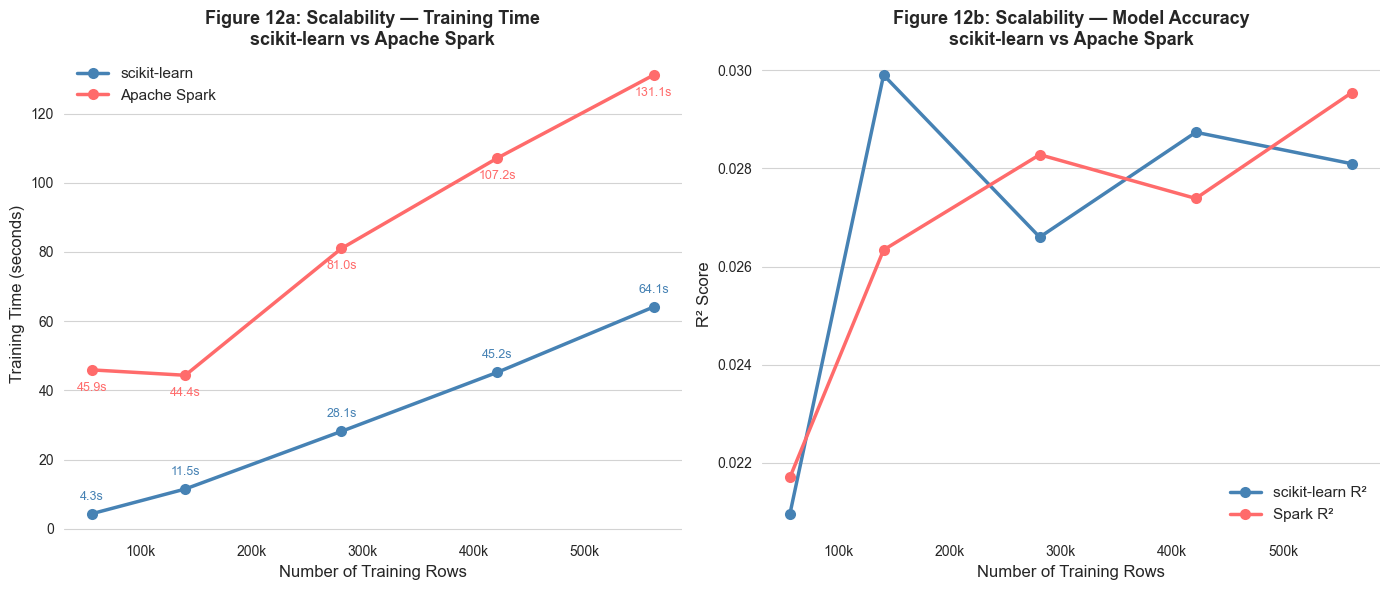

Figure 12 saved!

Key scalability finding:
sklearn time growth: 4.3s → 64.1s (14.9x increase)
Spark time growth:   45.9s → 131.1s (2.9x increase)


In [43]:
# ── SCALABILITY COMPARISON PLOT ───────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor='white')

data_sizes = [int(561830 * f) for f in fractions]

# Plot 1 — Training time comparison
axes[0].set_facecolor('white')
axes[0].plot(data_sizes, sklearn_times,
             'o-', color='#4682B4', linewidth=2.5,
             markersize=8, label='scikit-learn')
axes[0].plot(data_sizes, spark_times,
             'o-', color='#FF6B6B', linewidth=2.5,
             markersize=8, label='Apache Spark')
# Add data labels
for i, (x, ys, ysp) in enumerate(
        zip(data_sizes, sklearn_times, spark_times)):
    axes[0].annotate(f'{ys:.1f}s',
                     (x, ys), textcoords='offset points',
                     xytext=(0, 10), ha='center', fontsize=9,
                     color='#4682B4')
    axes[0].annotate(f'{ysp:.1f}s',
                     (x, ysp), textcoords='offset points',
                     xytext=(0, -15), ha='center', fontsize=9,
                     color='#FF6B6B')
    axes[0].set_xlabel('Number of Training Rows', fontsize=12)
axes[0].set_ylabel('Training Time (seconds)', fontsize=12)
axes[0].set_title('Figure 12a: Scalability — Training Time\n'
                  'scikit-learn vs Apache Spark',
                  fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].yaxis.grid(True, color='lightgrey', linewidth=0.8)
axes[0].set_axisbelow(True)

# Format x axis
axes[0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))
# Plot 2 — R² comparison
axes[1].set_facecolor('white')
axes[1].plot(data_sizes, sklearn_r2s,
             'o-', color='#4682B4', linewidth=2.5,
             markersize=8, label='scikit-learn R²')
axes[1].plot(data_sizes, spark_r2s,
             'o-', color='#FF6B6B', linewidth=2.5,
             markersize=8, label='Spark R²')

axes[1].set_xlabel('Number of Training Rows', fontsize=12)
axes[1].set_ylabel('R² Score', fontsize=12)
axes[1].set_title('Figure 12b: Scalability — Model Accuracy\n'
                  'scikit-learn vs Apache Spark',
                  fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].yaxis.grid(True, color='lightgrey', linewidth=0.8)
axes[1].set_axisbelow(True)
axes[1].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))
plt.tight_layout()
plt.savefig('figure12_scalability.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

print("Figure 12 saved!")
print("\nKey scalability finding:")
print(f"sklearn time growth: {sklearn_times[0]:.1f}s → "
      f"{sklearn_times[-1]:.1f}s "
      f"({sklearn_times[-1]/sklearn_times[0]:.1f}x increase)")
print(f"Spark time growth:   {spark_times[0]:.1f}s → "
      f"{spark_times[-1]:.1f}s "
      f"({spark_times[-1]/spark_times[0]:.1f}x increase)")
